#### Starting simple Finetuning experiments

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import requests
from dotenv import load_dotenv

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [4]:
import torch
import torch.nn as nn 
from torch.nn import functional as F
import tiktoken

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device

'cuda'

In [ ]:
load_dotenv( Path.cwd() / "env.env")
PATH_TO_DATA_DIR = Path.cwd() / "dataset"
PATH_TO_DATA_DIR

PosixPath('/storage/ice1/1/0/vchopra37/projects/learning_env/dataset')

### Step-1:- Loading Dataset (Spam)

In [6]:
from model_training.artifacts.data.post_train_dataset.spam_loader import load_dataset, create_balanced_dataset, random_split

In [61]:
df = load_dataset(PATH_TO_DATA_DIR)
NUM_CLASSES = len(set(df['Label']))
print(df["Label"].value_counts())

/storage/ice1/1/0/vchopra37/projects/learning_env/dataset/sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extraction.
Label
ham     4825
spam     747
Name: count, dtype: int64


(1045, 2) (149, 2)


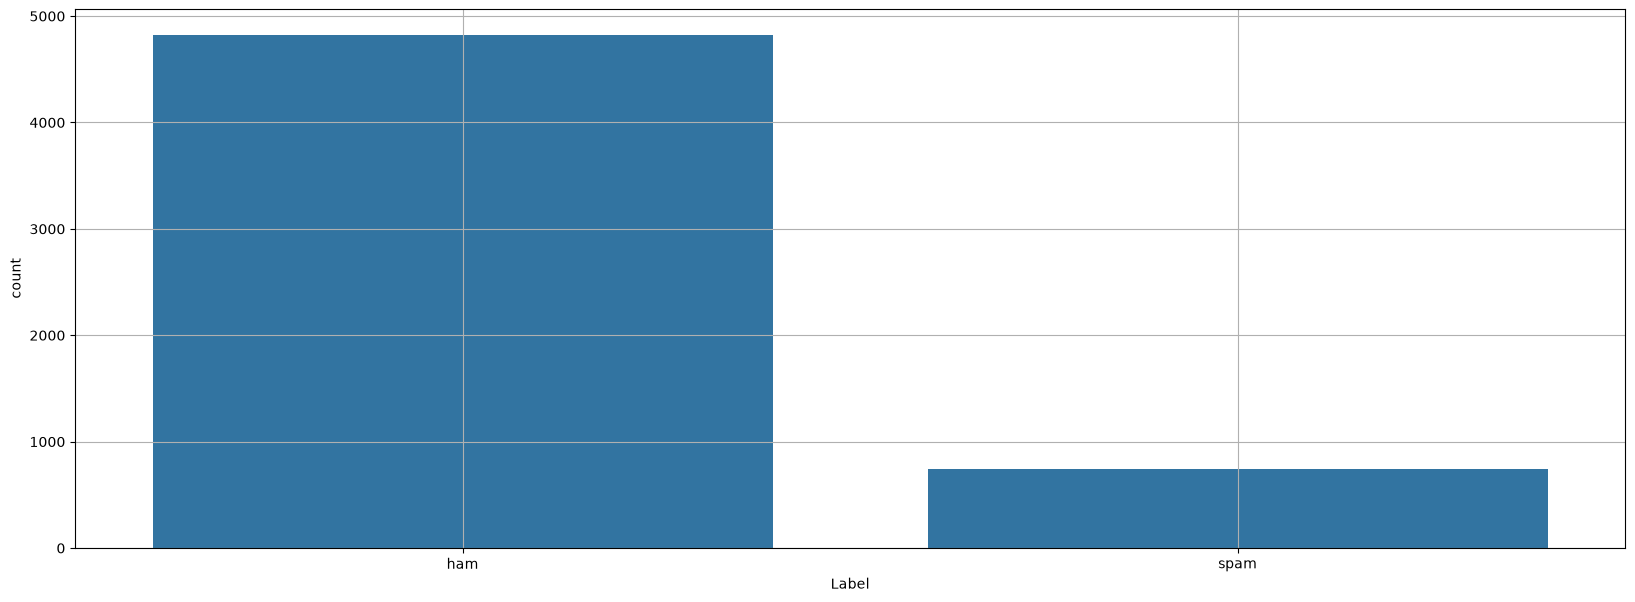

In [34]:
print(train_df.shape, val_df.shape)
plt.figure(figsize =(20, 7))
sns.countplot(x="Label", data= df)
# plt.xticks(rotation=90, ha="right")
plt.grid()
plt.show()

In [8]:
balanced_df = create_balanced_dataset(df)
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})    
balanced_df.shape

(1494, 2)

In [9]:
train_df, val_df, test_df = random_split(balanced_df, 0.7, 0.1)
print(train_df.columns)
train_df.shape,val_df.shape, test_df.shape

Index(['Label', 'Text'], dtype='str')


((1045, 2), (149, 2), (300, 2))

### Basic Finetuning

In [11]:
from model_training.artifacts.data.pytorch_dataloader import CustomDataLoader, return_dataloader

In [12]:
tokenizer = tiktoken.get_encoding("gpt2")
pad_token_id = (tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))[0]

In [13]:
train_dataset = CustomDataLoader(df = train_df, 
                                train_column ="Text", 
                                label_column = "Label",
                                tokenizer= tokenizer, pad_token_id = pad_token_id)
max_length = train_dataset.max_length
max_length

120

In [14]:
val_dataset = CustomDataLoader(df = val_df, train_column ="Text", label_column = "Label",
                            tokenizer= tokenizer, pad_token_id = pad_token_id, max_length=max_length)
test_dataset = CustomDataLoader(df = test_df, train_column ="Text", label_column = "Label",
                            tokenizer= tokenizer, pad_token_id = pad_token_id, max_length=max_length)

In [15]:
num_workers = 0
batch_size = 8
torch.manual_seed(123)

In [16]:
train_loader = return_dataloader(dataset=train_dataset, batch_size=batch_size, shuffle=True, workers=num_workers, drop_last=True)
val_loader = return_dataloader(dataset=val_dataset, batch_size=batch_size, shuffle=True, workers=num_workers, drop_last=True)
test_loader = return_dataloader(dataset=test_dataset, batch_size=batch_size, shuffle=True, workers=num_workers, drop_last=True)

In [17]:
for input_batch, target_batch in train_loader:
    pass
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [18]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
18 validation batches
37 test batches


### Step-2: - Loading the Model 

In [19]:
from model_training.artifacts.model.load_model.gpt2.configs import load_model_config

In [20]:
config = load_model_config(train_dataset.max_length, "gpt2-small")

loading wights from pretrained gpt: gpt2-small
{'n_layer': 12, 'n_head': 12, 'emb_dim': 768}


In [94]:
from model_training.artifacts.model.load_model.gpt2.model import GPT

In [95]:
model = GPT.from_pretrained(config, "gpt2")
print(f"Model Loaded: {model}")
model.eval()
model = model.to(device)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model Loaded: GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='tanh')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


### Testing the model

In [96]:
print(config.input_prompt)
enc_input = tokenizer.encode(config.input_prompt)
enc_input = torch.tensor(enc_input, dtype = torch.long).to(device)
enc_input = enc_input.unsqueeze(0)
print(enc_input, (enc_input).shape)

Every effort moves
tensor([[6109, 3626, 6100]], device='cuda:0') torch.Size([1, 3])


In [97]:
from model_training.artifacts.model.components.inference.inference import generate_prob, gen_sample

In [98]:
decoded_text = gen_sample(model, enc_input, max_new_tokens=40, context_len=config.context_len)
print(tokenizer.decode(decoded_text.squeeze(0).tolist()))

Every effort moves on from this topic, and in many cases the entire process becomes increasingly difficult. Many of the people present also take issue with the current system of accountability.

The following topics are


#### Finetuning Model Changes -> Depending on dataset

In [99]:
model

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='tanh')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [100]:
torch.manual_seed(123)

In [101]:
## First setting all the Layers to non Training Mode -> Setting Gradient to False -> Freezing the model
for param in model.parameters():
    param.requires_grad = False
    
## Setting the last layer classification head based on dataset
model.lm_head = nn.Linear(in_features=config.emb_dim, out_features=NUM_CLASSES)

In [102]:
### Setting Last 3-4 layers as trainable

# for i in model.transformer.h[:-LAST_X_LAYERS]:
#     i.requires_grad = True


In [103]:
LAST_X_LAYERS = 2
for param in model.transformer.h[-LAST_X_LAYERS:].parameters():
    # print("here->", i)
    param.requires_grad=True
for param in model.transformer.ln_f.parameters():
    param.requires_grad = True

In [106]:
## print all Trainable layer
for name, param in model.named_parameters():
    if param.requires_grad == True:
        print(name, param.requires_grad, end = '|           ')


transformer.h.10.ln_1.weight True|           transformer.h.10.ln_1.bias True|           transformer.h.10.attn.c_attn.weight True|           transformer.h.10.attn.c_attn.bias True|           transformer.h.10.attn.c_proj.weight True|           transformer.h.10.attn.c_proj.bias True|           transformer.h.10.ln_2.weight True|           transformer.h.10.ln_2.bias True|           transformer.h.10.mlp.c_fc.weight True|           transformer.h.10.mlp.c_fc.bias True|           transformer.h.10.mlp.c_proj.weight True|           transformer.h.10.mlp.c_proj.bias True|           transformer.h.11.ln_1.weight True|           transformer.h.11.ln_1.bias True|           transformer.h.11.attn.c_attn.weight True|           transformer.h.11.attn.c_attn.bias True|           transformer.h.11.attn.c_proj.weight True|           transformer.h.11.attn.c_proj.bias True|           transformer.h.11.ln_2.weight True|           transformer.h.11.ln_2.bias True|           transformer.h.11.mlp.c_fc.weight True|      

In [107]:
trainable_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_count)


14178818


In [ ]:
## After Changing Last Layer -> Only 2 classes 
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
inputs = inputs.to(device)
model = model.to(device)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

with torch.no_grad():
    loss, outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)

Inputs: tensor([[5211,  345,  423,  640]], device='cuda:0')
Inputs dimensions: torch.Size([1, 4])
Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]], device='cuda:0')
Outputs dimensions: torch.Size([1, 4, 2])
